In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.utils import class_weight

# Deep Learning
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
# ==============================


In [2]:

# ==============================
# 2. LOAD DATA
# ==============================
data = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")

# Drop irrelevant columns
data = data.drop([
    "Customer_ID","Customer_Name","Transaction_ID",
    "Customer_Contact","Customer_Email",
    "Merchant_ID","Transaction_Currency"
], axis=1)

In [3]:
# 3. ENCODING
# ==============================
categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [4]:
# ==============================
# 4. SPLIT DATA
# ==============================
X = data.drop("Is_Fraud", axis=1)
y = data["Is_Fraud"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
# ==============================


In [5]:
# 5. OUTLIER REMOVAL (FIXED)
# ==============================
numerical_cols = x_train.select_dtypes(include=['number']).columns

mask = (y_train == 0)  # only non-fraud

for col in numerical_cols:
    Q1 = x_train.loc[mask, col].quantile(0.25)
    Q3 = x_train.loc[mask, col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask &= (x_train[col] >= lower) & (x_train[col] <= upper)

# Keep all fraud rows
final_mask = mask | (y_train == 1)

x_train = x_train[final_mask]
y_train = y_train[final_mask]
# ==============================


In [6]:
# ==============================
# 6. SCALING
# ==============================
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# ==============================


In [7]:
# 7. MACHINE LEARNING MODELS
# ==============================
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB()
}

metrics = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': []}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    metrics['Model'].append(name)
    metrics['Accuracy'].append(accuracy_score(y_test, y_pred) * 100)
    metrics['Precision'].append(precision_score(y_test, y_pred) * 100)
    metrics['Recall'].append(recall_score(y_test, y_pred) * 100)
# ==============================


c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Parth\anaconda3\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Parth\anac

In [8]:
# ==============================
# 8. CLASS WEIGHTS (IMPORTANT)
# ==============================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
# ==============================


In [9]:
# ==============================
# 9. RESHAPE FOR DL MODELS
# ==============================
x_train_dl = np.array(x_train).reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_dl = np.array(x_test).reshape((x_test.shape[0], x_test.shape[1], 1))
# ==============================


In [10]:
# ==============================
# 10. LSTM MODEL (IMPROVED)
# ==============================
lstm_model = Sequential([
    Input(shape=(x_train_dl.shape[1], 1)),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = lstm_model.fit(
    x_train_dl, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

# Predictions (LOWER THRESHOLD)
y_pred_lstm = (lstm_model.predict(x_test_dl) > 0.3).astype("int32")

metrics['Model'].append("LSTM")
metrics['Accuracy'].append(accuracy_score(y_test, y_pred_lstm) * 100)
metrics['Precision'].append(precision_score(y_test, y_pred_lstm) * 100)
metrics['Recall'].append(recall_score(y_test, y_pred_lstm) * 100)
# ==============================


Epoch 1/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - accuracy: 0.5090 - loss: 0.6943 - val_accuracy: 0.0513 - val_loss: 0.7014
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.4773 - loss: 0.6943 - val_accuracy: 0.0500 - val_loss: 0.6995
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 103s 27ms/step - accuracy: 0.5263 - loss: 0.6937 - val_accuracy: 0.0500 - val_loss: 0.7032
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 176s 47ms/step - accuracy: 0.4240 - loss: 0.6936 - val_accuracy: 0.9500 - val_loss: 0.6867
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 223s 59ms/step - accuracy: 0.4230 - loss: 0.6937 - val_accuracy: 0.9492 - val_loss: 0.6914
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 224s 49ms/step - accuracy: 0.5093 - loss: 0.6940 - val_accuracy: 0.0529 - val_loss: 0.7058
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - accuracy: 0.4638 - loss: 0.6936 - val_accuracy: 0.9500 - val_loss: 0.6532
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 75s 20ms/step - accuracy: 0.49

In [11]:
# ==============================
# 11. TRANSFORMER MODEL
# ==============================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dropout(dropout)(ffn)
    ffn = Dense(inputs.shape[-1])(ffn)

    return LayerNormalization(epsilon=1e-6)(x + ffn)


inputs = Input(shape=(x_train_dl.shape[1], 1))

x = transformer_encoder(inputs, 64, 4, 128)
x = transformer_encoder(x, 64, 4, 128)
x = transformer_encoder(x, 64, 4, 128)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_trans = transformer_model.fit(
    x_train_dl, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

# Predictions
y_pred_trans = (transformer_model.predict(x_test_dl) > 0.3).astype("int32")

metrics['Model'].append("Transformer")
metrics['Accuracy'].append(accuracy_score(y_test, y_pred_trans) * 100)
metrics['Precision'].append(precision_score(y_test, y_pred_trans) * 100)
metrics['Recall'].append(recall_score(y_test, y_pred_trans) * 100)
# ==============================


Epoch 1/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 128s 32ms/step - accuracy: 0.4977 - loss: 0.6936 - val_accuracy: 0.9500 - val_loss: 0.6917
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - accuracy: 0.4733 - loss: 0.6936 - val_accuracy: 0.0500 - val_loss: 0.6935
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 101s 27ms/step - accuracy: 0.5800 - loss: 0.6936 - val_accuracy: 0.0500 - val_loss: 0.6992
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 127s 34ms/step - accuracy: 0.2918 - loss: 0.6936 - val_accuracy: 0.9500 - val_loss: 0.6924
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 111s 30ms/step - accuracy: 0.5146 - loss: 0.6935 - val_accuracy: 0.9500 - val_loss: 0.6893
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 100s 27ms/step - accuracy: 0.5513 - loss: 0.6936 - val_accuracy: 0.9500 - val_loss: 0.6924
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 60s 16ms/step - accuracy: 0.4079 - loss: 0.6936 - val_accuracy: 0.9500 - val_loss: 0.6868
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 62s 17ms/step - accuracy: 0.5

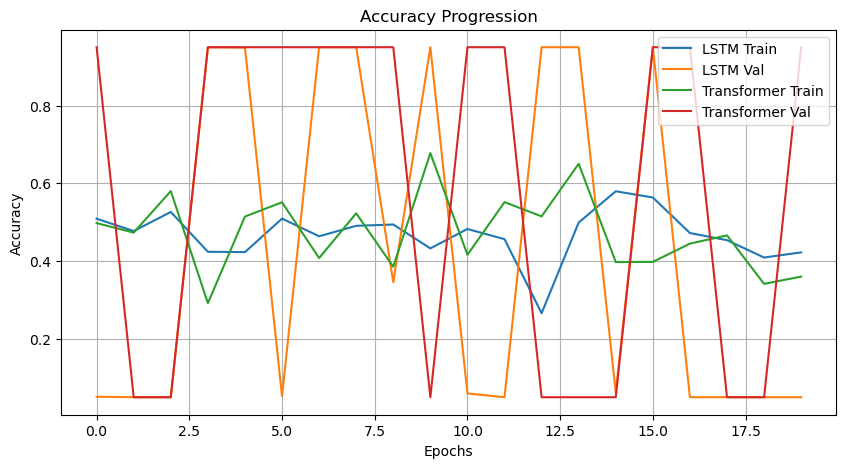

In [12]:
# ==============================
# 12. ACCURACY GRAPH (IMPORTANT)
# ==============================
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val')

plt.plot(history_trans.history['accuracy'], label='Transformer Train')
plt.plot(history_trans.history['val_accuracy'], label='Transformer Val')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Progression")
plt.legend()
plt.grid()

plt.show()
# ==============================


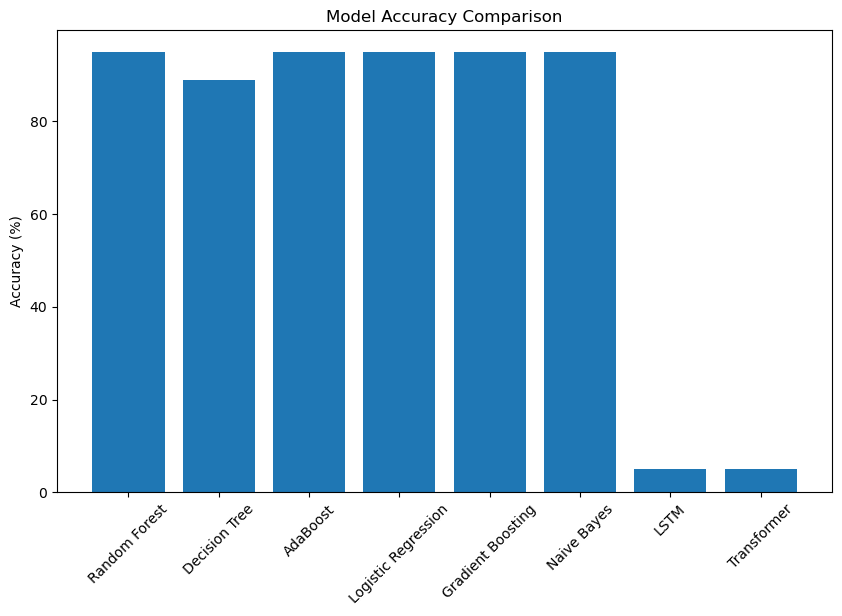

                 Model  Accuracy  Precision      Recall
0        Random Forest    94.886   0.000000    0.000000
1        Decision Tree    88.876   5.082212    6.648416
2             AdaBoost    94.886   0.000000    0.000000
3  Logistic Regression    94.886   0.000000    0.000000
4    Gradient Boosting    94.882   0.000000    0.000000
5          Naive Bayes    94.886   0.000000    0.000000
6                 LSTM     5.114   5.114000  100.000000
7          Transformer     5.114   5.114000  100.000000


In [13]:
# ==============================
# 13. FINAL COMPARISON
# ==============================
metrics_df = pd.DataFrame(metrics)

plt.figure(figsize=(10,6))
plt.bar(metrics_df['Model'], metrics_df['Accuracy'])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

print(metrics_df)
# ==============================